In [2]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   # 修改 1：新增，用于手动加载 Arial.ttf


# =========================
# 修改 2：只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"   # 改成你的 arial.ttf 实际路径
USE_ARIAL_TTF = True                # True = 从 ttf 文件加载 Arial；False = 直接用系统字体名


_PUB_FONT_NAME = None


def load_pub_font():
    """
    手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。
    这样可以避免系统装了 Arial 但 matplotlib 仍然找不到的问题。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")

        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 90,
    "double": 180,
}


FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_medium": ("single", 75),
    "double_short":  ("double", 70),
    "double_medium": ("double", 100),
    "double_large":  ("double", 140),
}


_SHARED_FONT_SIZES = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()   # 修改 3：每次设置风格前，先确保 Arial.ttf 已经加载

    base = {
        # 修改 4：不再直接写死 "Arial"，而是使用 ttf 文件真实识别到的字体名
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],

        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # 稍粗一些的论文图风格
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",

        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,

        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,

        "savefig.dpi": 600,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()

Using font: Arial


/tmp/ipykernel_2494874/3656822916.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved: ./figures/surf_tension_radius.png


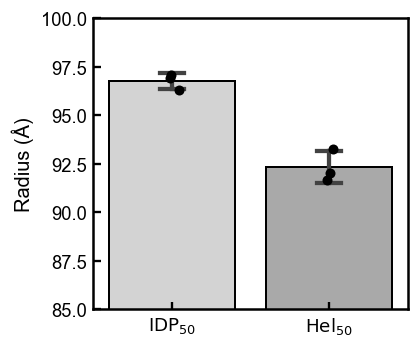

/tmp/ipykernel_2494874/3656822916.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved: ./figures/surf_tension_tension.png


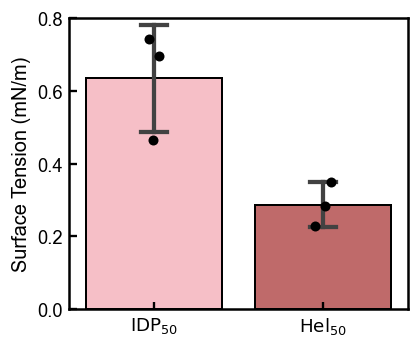

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import os

# ==========================================
# 1. 原始数据 (直接嵌入代码，确保脚本自包含)
# ==========================================
raw_data_group1 = """
Block [10000.0-11999.0 ns]: Chains=50.0[50-50], R=95.3Å, γ=0.981 mN/m (γ20=0.972, γ22=0.991)
Block [12000.0-13999.0 ns]: Chains=50.0[50-50], R=96.3Å, γ=0.293 mN/m (γ20=0.285, γ22=0.301)
Block [14000.0-15999.0 ns]: Chains=50.0[50-50], R=97.3Å, γ=0.454 mN/m (γ20=0.445, γ22=0.464)
Block [16000.0-17999.0 ns]: Chains=50.0[50-50], R=96.4Å, γ=0.683 mN/m (γ20=0.676, γ22=0.690)
Block [18000.0-19999.0 ns]: Chains=50.0[50-50], R=96.1Å, γ=1.067 mN/m (γ20=1.059, γ22=1.075)

Block [10000.0-11999.0 ns]: Chains=49.0[48-50], R=95.8Å, γ=0.269 mN/m (γ20=0.263, γ22=0.276)
Block [12000.0-13999.0 ns]: Chains=49.9[49-50], R=97.2Å, γ=0.514 mN/m (γ20=0.507, γ22=0.521)
Block [14000.0-15999.0 ns]: Chains=50.0[50-50], R=96.7Å, γ=0.691 mN/m (γ20=0.684, γ22=0.699)
Block [16000.0-17999.0 ns]: Chains=50.0[50-50], R=97.9Å, γ=0.470 mN/m (γ20=0.462, γ22=0.477)
Block [18000.0-19999.0 ns]: Chains=50.0[49-50], R=97.6Å, γ=0.384 mN/m (γ20=0.377, γ22=0.391)

Block [10000.0-11999.0 ns]: Chains=49.0[49-50], R=96.8Å, γ=0.739 mN/m (γ20=0.731, γ22=0.747)
Block [12000.0-13999.0 ns]: Chains=49.8[49-50], R=96.6Å, γ=1.348 mN/m (γ20=1.339, γ22=1.357)
Block [14000.0-15999.0 ns]: Chains=50.0[50-50], R=97.5Å, γ=0.659 mN/m (γ20=0.651, γ22=0.667)
Block [16000.0-17999.0 ns]: Chains=50.0[50-50], R=96.9Å, γ=0.511 mN/m (γ20=0.503, γ22=0.519)
Block [18000.0-19999.0 ns]: Chains=49.3[48-50], R=96.8Å, γ=0.449 mN/m (γ20=0.439, γ22=0.459)
"""

raw_data_group2 = """
Block [10000.0-11999.0 ns]: Chains=49.0[49-50], R=91.1Å, γ=0.212 mN/m (γ20=0.206, γ22=0.218)
Block [12000.0-13999.0 ns]: Chains=49.0[49-49], R=91.1Å, γ=0.233 mN/m (γ20=0.227, γ22=0.239)
Block [14000.0-15999.0 ns]: Chains=49.4[48-50], R=91.9Å, γ=0.298 mN/m (γ20=0.292, γ22=0.304)
Block [16000.0-17999.0 ns]: Chains=50.0[50-50], R=91.2Å, γ=0.389 mN/m (γ20=0.383, γ22=0.396)
Block [18000.0-19999.0 ns]: Chains=50.0[49-50], R=94.8Å, γ=0.621 mN/m (γ20=0.614, γ22=0.627)

Block [10000.0-11999.0 ns]: Chains=49.0[48-50], R=93.3Å, γ=0.141 mN/m (γ20=0.136, γ22=0.146)
Block [12000.0-13999.0 ns]: Chains=49.0[49-49], R=91.5Å, γ=0.234 mN/m (γ20=0.227, γ22=0.240)
Block [14000.0-15999.0 ns]: Chains=49.9[49-50], R=92.7Å, γ=0.211 mN/m (γ20=0.205, γ22=0.217)
Block [16000.0-17999.0 ns]: Chains=50.0[50-50], R=90.7Å, γ=0.276 mN/m (γ20=0.269, γ22=0.282)
Block [18000.0-19999.0 ns]: Chains=50.0[50-50], R=90.2Å, γ=0.275 mN/m (γ20=0.268, γ22=0.281)

Block [10000.0-11999.0 ns]: Chains=47.9[47-48], R=95.0Å, γ=0.198 mN/m (γ20=0.192, γ22=0.203)
Block [12000.0-13999.0 ns]: Chains=48.1[48-49], R=91.3Å, γ=0.192 mN/m (γ20=0.186, γ22=0.198)
Block [14000.0-15999.0 ns]: Chains=48.5[48-50], R=93.4Å, γ=0.193 mN/m (γ20=0.187, γ22=0.199)
Block [16000.0-17999.0 ns]: Chains=49.1[49-50], R=94.0Å, γ=0.332 mN/m (γ20=0.325, γ22=0.338)
Block [18000.0-19999.0 ns]: Chains=49.9[49-50], R=92.6Å, γ=0.499 mN/m (γ20=0.492, γ22=0.506)
"""

# ==========================================
# 2. 数据解析
# ==========================================
def parse_to_dataframe(text, label):
    # 正则提取所有数值
    r_all = [float(x) for x in re.findall(r'R=([\d\.]+)', text)]
    g_all = [float(x) for x in re.findall(r'γ=([\d\.]+)', text)]

    # 每5个Block作为一个Run取平均值，得到 N=3
    runs = []
    for i in range(0, len(r_all), 5):
        runs.append({
            'Group': label,
            'Radius': np.mean(r_all[i:i+5]),
            'Tension': np.mean(g_all[i:i+5])
        })
    return runs

# 构建 DataFrame
data = parse_to_dataframe(raw_data_group1, r'$\mathrm{IDP}_{50}$') + \
       parse_to_dataframe(raw_data_group2, r'$\mathrm{Hel}_{50}$')
df = pd.DataFrame(data)

# ==========================================
# 3. 绘图（拆分为两个独立图）
# ==========================================
# 设置全局字体样式


# 绘图配置 [数据列名, Y轴标签, 颜色组, Y轴范围]
configs = [
    ['Radius', 'Radius (Å)', ['#D3D3D3', '#A9A9A9'], (85, 100)],
    ['Tension', 'Surface Tension (mN/m)', ['#FFB6C1', '#CD5C5C'], (0, 0.8)]
]

# 输出目录
out_dir = "./figures"
os.makedirs(out_dir, exist_ok=True)

for col, ylabel, colors, ylim in configs:
    FIG_PRESET = "single_medium"
    fig, ax = new_subplots(1, 1, preset=FIG_PRESET)

    # A. 柱状图 (errorbar='sd' 表示绘制标准差)
    sns.barplot(
        x='Group', y=col, data=df,
        palette=colors, edgecolor='black',
        errorbar='sd', capsize=0.15, linewidth=1.2,
        ax=ax, zorder=1
    )

    # B. 散点图 (展示 N=3 的原始点)
    sns.stripplot(
        x='Group', y=col, data=df,
        color='black', size=6, jitter=0.05,
        ax=ax, zorder=2
    )

    # C. 细节美化
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.set_ylim(ylim)

    ax.tick_params(top=False, right=False)

    fig.tight_layout(pad=0.8)

    filename = os.path.join(out_dir, f"surf_tension_{col.lower()}.png")
    savefig_pub(fig, filename, dpi=600, tight=False)
    print(f"Saved: {filename}")

    plt.show()